In [5]:
from opty import Problem, create_objective_function, parse_free
import sympy as sp
import numpy as np
import scipy as sc
import time as tm
import pickle
import sympy.physics.mechanics as me
import sys
sys.path.insert(0, "..")
from importlib import reload
import matplotlib.pyplot as plt
import equations as eq
reload (eq);
import trajectory_lib as tr
reload (tr);

participant = '1LU'
motion_list  =  ['All_motions']
GH_seq = 'YZY'
include_q_clavicula_init = True

motion_folder = motion_list[0]
motion_name = motion_list[0]

OS_struct = sc.io.loadmat('../Motions/'+participant+'/OS_model.mat')
# optim_params_struct = sc.io.loadmat('../Motions/'+participant+'/'+motion_name+'/params_optimized_'+motion_name+'.mat')
include_activation_dynamics = False

act_w = 1
vel_w = 0.1

MM,FO,q,u,fr,frstar,kinematical,xdot,first_elips_scale,elips_trans = eq.create_eoms_quat_w_RF(OS_struct,derive = 'numeric',gen_matlab_functions = 0)
# TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = None, derive = 'numeric')

[0.22119215838351078]
[0.22119215838351078, 1.000185567459798]
[0.22119215838351078, 1.000185567459798, 2.909385831968754]
[0.22119215838351078, 1.000185567459798, 2.909385831968754, 0.7747397137227582]
[0.22119215838351078, 1.000185567459798, 2.909385831968754, 0.7747397137227582, 0.7747397137227582]
[0.22119215838351078, 1.000185567459798, 2.909385831968754, 0.7747397137227582, 0.7747397137227582, 0.7443966868675843]


ValueError: too many values to unpack (expected 10)

In [ ]:
reload(eq)
eq.max_GH_stab(3)

atan2(-r2, -r1)**2 + atan2(-r3, -r1)**2
Matrix([[-2*r2*atan2(-r2, -r1)/(r1**2 + r2**2) - 2*r3*atan2(-r3, -r1)/(r1**2 + r3**2), 2*r1*atan2(-r2, -r1)/(r1**2 + r2**2), 2*r1*atan2(-r3, -r1)/(r1**2 + r3**2)]])


(<function _lambdifygenerated(r1, r2, r3)>,
 <function _lambdifygenerated(r1, r2, r3)>)

In [ ]:
# # params_init = {**fmax_init, **lceopt_init}
# params_init = fmax_init
# # params_range = {**fmax_range, **lceopt_range}
# params_range = fmax_range
# myKeys = list(params_init.keys())
# myKeys.sort()

# # Sorted Dictionary
# sd = {i: params_init[i] for i in myKeys}
# sorted_params_init = np.array([*sd.values()])
# num_params = len(sorted_params_init)
# print(sd)

In [ ]:
# reload(eq)
# eq.optimize_parameters(params_init,mus_groups)

In [6]:
reload(eq)
reload(tr)
clav_pos = [0.4]
weights = [14]
diff_weights = [1]
w_optim_params = 1e-1
name_w_param = 'e1'
optim_params = [1]

for iweight in range(len(weights)):
    for optimize in optim_params:
        if optimize == 0:
            optim_params_struct = sc.io.loadmat('../Motions/'+participant+'/'+motion_name+'/params_optimized_'+motion_name+'_'+str(weights[iweight])+'_'+name_w_param+'.mat')
            TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = optim_params_struct, derive = 'numeric')
        else:
            TE,activations,TE_conoid, fmax_init, fmax_range, lceopt_init, lceopt_range, mus_groups = eq.polynomials_quat(OS_struct,q,u,optim_params = None, derive = 'numeric')
            params_init = {**fmax_init, **lceopt_init}
            params_range = {**fmax_range, **lceopt_range}
            myKeys = list(params_init.keys())
            myKeys.sort()
            sd = {i: params_init[i] for i in myKeys}
            sorted_params_init = np.array([*sd.values()])
            num_params = len(sorted_params_init)
            print('num_params = ', num_params)

        if include_q_clavicula_init:
            q_clavicula_init = sc.io.loadmat('../Motions/'+participant+'/'+motion_list[0]+'/res_quat_'+motion_list[0]+'_200.mat')['data']['q_clavicula_init']
            # q_clavicula_init = sc.io.loadmat('../Motions/'+participant+'/'+motion_list[0]+'/res_quat_Scabduction_scaling_234.mat')['data']['q_clavicula_init']

        weight = int(180)
        struct_name = 'res_quat_'+motion_list[0]+'_'+str(weight)
        eoms_implicit = sp.Matrix(kinematical).col_join(fr+frstar+TE+sp.Matrix(TE_conoid))
        traj_w = weight

        if include_activation_dynamics:
            excitations = []
            act_ode = []
            for i in range(len(activations)):
                excitations.append(me.dynamicsymbols('exc'+str(activations[i])[3:-3]))
                current_mus_ind = int(str(activations[i])[4:-3])
                current_mus = OS_struct['model']['muscles'].item()[0,(current_mus_ind-1)]
                t_act = current_mus['tact'][0,0].item()
                t_deact = current_mus['tdeact'][0,0].item()
                act_ode.append(activations[i].diff() - eq.act_dynamics(activations[i],excitations[i]))
            # print('act_ode = ', act_ode)
            sp_act_ode = sp.Matrix(act_ode)
            eoms_implicit = eoms_implicit.col_join(sp_act_ode)

        reload(eq)
        num_nodes = 301
        file = '../Motions/' + participant + '/' + motion_folder + '/' + motion_name
        traj_original, interval_value, time = tr.exp_trajectory_quat(file,num_nodes)
        traj = tr.exp_trajectory_quat_myobj(traj_original,0.4)
        emg, indexes = tr.exp_emg('../Motions/'+participant+'/'+motion_folder+'/EMG_'+participant+'_all.mat', num_nodes = num_nodes,EMG_num = 1)

        if include_activation_dynamics:
            state_symbols = tuple(q+u+activations)
            specified_symbols = tuple(excitations)
        else:
            state_symbols = tuple(q+u)
            specified_symbols = tuple(activations)

        num_states = len(state_symbols) 
        num_q = len(q)
        num_u = len(u)
        num_inputs = len(specified_symbols)
        t = me.dynamicsymbols._t
        objective_traj,objective_traj_jac = eq.custom_objective_quat(num_q,interval_value,0.4,True)

        objective_act,objective_act_jac = eq.min_activation(activations,interval_value)
        objective_exc,objective_exc_jac = eq.min_activation(activations,interval_value)

        obj_min_diff,obj_min_diff_jac = eq.objective_activation_diff(num_nodes, interval_value)

        if optimize == 1:
            obj_opt_params, obj_opt_params_jac = eq.optimize_parameters(mus_groups)
        
        w_diff_vel = 1
        w_diff_act = 0
        w_diff_exc = 1e-2
        node1 = 0
        node2 = num_nodes//2
        node3 = num_nodes-1

        w_min_squared_act = 1
        w_min_squared_exc = 0
        
        if optimize == 1:
            if include_activation_dynamics:
                w_min_emg_act = 0
                w_min_emg_exc = weights[iweight] 
            else: 
                w_min_emg_act = weights[iweight]
                w_min_emg_exc = 0
        else:
            w_min_emg_act = 0
            w_min_emg_exc = 0


        def obj(free):
            # min_traj = traj_w * interval_value * np.sum((traj_original.flatten() - free[:10*num_nodes])**2)
            min_traj = traj_w * np.sum(objective_traj(np.split(free[:num_q*num_nodes],num_q),traj))
            # min_traj = traj_w * (objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node1],traj[:,node1]) + objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node2],traj[:,node2]) + objective_traj(np.array(np.split(free[:10*num_nodes],10))[:,node3],traj[:,node3]))

            min_vel_dif = w_diff_vel * np.sum((obj_min_diff(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))))

            # min_torque = act_w * interval_value * np.sum(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes]**2)
            min_torque = act_w * np.sum(objective_act(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs),emg,indexes,w_min_squared_act,w_min_emg_act))

            if optimize == 0:
                opt_params = 0
            else:
                opt_params = w_optim_params * obj_opt_params(*free[(num_states + num_inputs)*num_nodes:(num_states + num_inputs + num_params)*num_nodes])
            obj = (min_traj + min_torque+ min_vel_dif + opt_params)
            # min_act_dif = w_diff_act * np.sum((obj_min_diff(np.transpose(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs)))))
            if include_activation_dynamics:
                min_exc_dif = w_diff_exc * np.sum((obj_min_diff(np.transpose(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs)))))
                min_exc = act_w * np.sum(objective_exc(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs),emg,indexes,w_min_squared_exc,w_min_emg_exc))
                obj += (min_exc_dif + min_exc)

            return obj.item()

        def obj_grad(free):
            grad = np.zeros_like(free)
            # grad[:10*num_nodes] = traj_w * 2.0 * interval_value * (free[:10*num_nodes] - traj_original.flatten())
            grad[:num_q*num_nodes] += traj_w * np.concatenate(objective_traj_jac(np.split(free[:num_q*num_nodes],num_q),traj))

            # grad[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] = act_w * 2.0 * interval_value * free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] #+ w_diff_act * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs)))[0,:,:])))
            grad[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes] += act_w * np.concatenate(objective_act_jac(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_inputs)*num_nodes],num_inputs),emg,indexes,w_min_squared_act,w_min_emg_act))
            # print(np.shape(objective_exc_jac(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs),emg,indexes)))


            grad[num_q*num_nodes:(num_q + num_u)*num_nodes] += w_diff_vel * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))[0,:,:])))

            if optimize == 1:
                grad[(num_states + num_inputs)*num_nodes:(num_states + num_inputs + num_params)*num_nodes] += w_optim_params * obj_opt_params_jac(*free[(num_states + num_inputs)*num_nodes:(num_states + num_inputs + num_params)*num_nodes])[0]
            
            if include_activation_dynamics:
                grad[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + 2*num_inputs)*num_nodes] += w_diff_exc * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + 2*num_inputs)*num_nodes],num_inputs)))[0,:,:])))
                grad[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes] += np.concatenate(objective_exc_jac(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs),emg,indexes,w_min_squared_exc,w_min_emg_exc))

            
            # ## reach ##
            # first_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node1],traj[:,node1])))
            # second_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node2],traj[:,node2])))
            # third_grad_vals = np.array((objective_traj_jac(np.array(np.split(free[:10*num_nodes],10))[:,node3],traj[:,node3])))
            # # print(np.shape(first_grad_vals))
            # grad_traj = np.zeros((num_nodes,10))
            # grad_traj[node1,:] = first_grad_vals
            # grad_traj[node2,:] = second_grad_vals
            # grad_traj[node3,:] = third_grad_vals
            # grad[:10*num_nodes] = traj_w * np.concatenate(grad_traj.T)
            # ## end reach ##

            return grad
        
        print('obj_check', sum(obj_grad(np.zeros(num_states*num_nodes + num_inputs*num_nodes + num_params))))
        instance_constraints = []
        # for i in range(13):
        if include_q_clavicula_init:
            instance_constraints.append(state_symbols[0].func(0.0)-q_clavicula_init[0,0][0,0])
            instance_constraints.append(state_symbols[1].func(0.0)-q_clavicula_init[0,0][0,1])
            instance_constraints.append(state_symbols[2].func(0.0)-q_clavicula_init[0,0][0,2])
            instance_constraints.append(state_symbols[3].func(0.0)-q_clavicula_init[0,0][0,3])
        instance_constraints.append(state_symbols[4].func(0)**2 + state_symbols[5].func(0)**2 + state_symbols[6].func(0)**2 + state_symbols[7].func(0)**2 - 1) # AC
        instance_constraints.append(state_symbols[8].func(0)**2 + state_symbols[9].func(0)**2 + state_symbols[10].func(0)**2 + state_symbols[11].func(0)**2 - 1) # GH

        # instance_constraints.append(state_symbols[-1].func(0.0)-0) 
            
        bounds1 = (0.0,1.0)
        bounds = (bounds1,)*len(activations)
        bndrs = dict(zip(activations,bounds))
        if include_activation_dynamics:
            bndrs_exc = dict(zip(excitations,(bounds1,)*len(excitations)))
            bndrs.update(bndrs_exc)

        # SCq_bndr = {q[0] : (0.9, 1),}
        #             # q[1] : (-0.1, 0.25),
        #             # q[2] : (-0.45, -0.15),
        #             # q[3] : (-0.1, 0.25)}
        # bndrs.update(SCq_bndr)
        # ACq_bndr = {q[4] : (0.8, 1),}
        #             # q[5] : (-0.4, 0.35),}
        #             # q[6] : (0.3, 0.55),
        #             # q[7] : (-0.1, 0.15)}
        # bndrs.update(ACq_bndr)
        # GHq_bndr = {q[8] : (0.85, 1),
        #             q[12]: (00*np.pi/180, 40*np.pi/180)}
        # bndrs.update(GHq_bndr)
        for i in range(num_q):
            bndrs.update({q[i]: (min(traj_original[i,:])-0.05, max(traj_original[i,:])+0.05)})

        if optimize == 1:
            bndrs.update(params_range)
        print(bndrs)


        start = tm.time()
        prob = Problem(obj, obj_grad, eoms_implicit, state_symbols,
                    num_nodes, interval_value,
                    known_parameter_map={},
                    instance_constraints=instance_constraints,
                    bounds=bndrs,
                    integration_method='midpoint')


        time_to_create = tm.time() - start
        print(time_to_create)

        prob.add_option('limited_memory_max_history', 40)
        initial_guess = np.zeros(prob.num_free)
        # initial_guess[:13*num_nodes] = traj_original.flatten()
        # initial_guess[(num_states+num_inputs)*num_nodes:(num_states+num_inputs+num_params)*num_nodes] = sorted_params_init
        time_2_solve_start = tm.time()

        prob.add_option('max_iter',2500)
        initial_guess = np.ones(prob.num_free)*0.0
        # initial_guess[0:(num_q + num_u + num_inputs)*num_nodes] = tr.initial_guess_from_solution('../Motions/'+participant+'/'+motion_folder+'/res_quat_All_motions_204.mat',prob.num_free)[0:prob.num_free]
        initial_guess[:13*num_nodes] = traj_original.flatten()

        if optimize == 1:
            initial_guess[(num_states+num_inputs)*num_nodes:(num_states+num_inputs+num_params)*num_nodes] = np.ones(2*len(fmax_init.values()))
            
        solution, info = prob.solve(initial_guess)
        time_2_solve = tm.time() - time_2_solve_start
        print(info['status_msg'])
        print(info['obj_val'])
        act_obj = np.sum(solution[num_states*num_nodes:(num_states + num_inputs)*num_nodes]**2)
        objective_value = prob.obj_value
        print('Objective activations: ', act_obj)

        reload(tr)
        if optimize == 1:
            file_name = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '_optimize_'+str(weights[iweight])+'.mat'
        else:
            file_name = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '_use_optimized_'+str(weights[iweight])+'.mat'

        tr.sol2struct(solution,activations,num_q,num_u,num_inputs,num_nodes,time,objective_value,time_2_solve,file_name,include_activation_dynamics)

        # file_name_mot = '../Motions/'+participant+'/'+motion_folder+'/' + struct_name + '.mot'
        # tr.sol2mot_quat(solution, num_nodes, len(q), time, file_name_mot, GH_seq)

        if optimize == 1:
            optimized_params = dict(zip(myKeys, solution[(num_states + num_inputs)*num_nodes:(num_states + num_inputs + num_params)*num_nodes]))
            sc.io.savemat('../Motions/'+participant+'/'+motion_folder+'/params_optimized_'+motion_name+'_'+str(weights[iweight])+'_'+name_w_param+'.mat', {'optimized_params': optimized_params})
        prob.close()

NameError: name 'q' is not defined

In [ ]:
num_states

23

In [ ]:
inputss = np.ones(prob.num_free)
obj_grad(inputss)

array([267.10975456, 268.12066637, 266.57100947, ...,   0.        ,
         0.        ,   0.        ])

In [ ]:
# reload(tr)
# file_name = '../Motions/'+motion_folder+'/' + struct_name + '.mat'
# tr.sol2struct(solution,activations,num_q,num_u,num_inputs,num_nodes,time,objective_value,time_2_solve,file_name,False)

# file_name_mot = '../Motions/'+motion_folder+'/' + struct_name + '.mot'
# tr.sol2mot_quat(solution, num_nodes, len(q), time, file_name_mot, GH_seq)

In [ ]:
# solution[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes]

In [ ]:
# optimized_params = dict(zip(myKeys, solution[(num_q + num_u + num_inputs)*num_nodes:(num_q + num_u + num_inputs + num_params)*num_nodes]))
# sc.io.savemat('../Motions/'+participant+'/'+motion_folder+'/params_optimized_'+motion_name+'.mat', {'optimized_params': optimized_params})
# # optimized_params

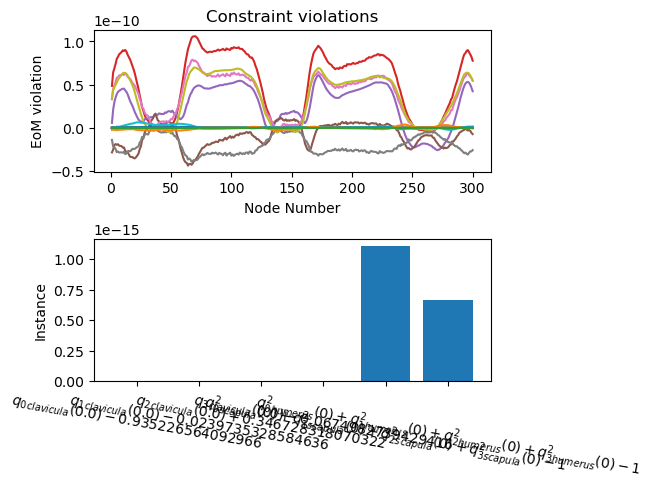

In [ ]:
_ = prob.plot_constraint_violations(solution)